<a href="https://colab.research.google.com/github/Rupa20052003/CODSOFT/blob/main/ML_Workshop_Day_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import numpy as np  #linear algebra
import pandas as pd   #data processing

import os

import warnings
warnings.filterwarnings("ignore")

 #visualization

import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

In [4]:

import pandas as pd
Bank =pd.read_csv("/content/Bank_Loan.csv")
Bank.head()


,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status
0,LP001002,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes
2,LP001005,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No
3,LP001006,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No
4,LP001008,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No


In [5]:
Bank.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Loan_ID              981 non-null    object
 1   Age                  981 non-null    int64 
 2   Gender               957 non-null    object
 3   Married              978 non-null    object
 4   Dependents           981 non-null    int64 
 5   Education            981 non-null    object
 6   Self_Employed        926 non-null    object
 7   ApplicantIncome      981 non-null    int64 
 8   LoanAmount           981 non-null    int64 
 9   Previous_Loan_Taken  981 non-null    object
 10  Cibil_Score          981 non-null    int64 
 11  Property_Area        981 non-null    object
 12  Customer_Bandwith    981 non-null    object
 13  Tenure               981 non-null    int64 
 14  Loan_Status          981 non-null    object
dtypes: int64(6), object(9)
memory usage: 115.1+ KB


In [6]:

Bank.isnull().sum()

,0
Loan_ID,0
Age,0
Gender,24
Married,3
Dependents,0
Education,0
Self_Employed,55
ApplicantIncome,0
LoanAmount,0
Previous_Loan_Taken,0


In [7]:

Bank.head()

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status
0,LP001002,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes
2,LP001005,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No
3,LP001006,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No
4,LP001008,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No


In [8]:
Bank.Married.value_counts(dropna=False)

,count
Married,
Yes,631
No,347
NaN,3


In [10]:
for i in ['Married' , 'Gender' , 'Self_Employed']:
   Bank[i].fillna(Bank[i].mode()[0] , inplace=True)


In [11]:
Bank.Married.value_counts(dropna=False)

,count
Married,
Yes,634
No,347


In [12]:
Bank.isnull().sum()

,0
Loan_ID,0
Age,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
LoanAmount,0
Previous_Loan_Taken,0


In [13]:
Bank.head()

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status
0,LP001002,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes
2,LP001005,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No
3,LP001006,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No
4,LP001008,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No


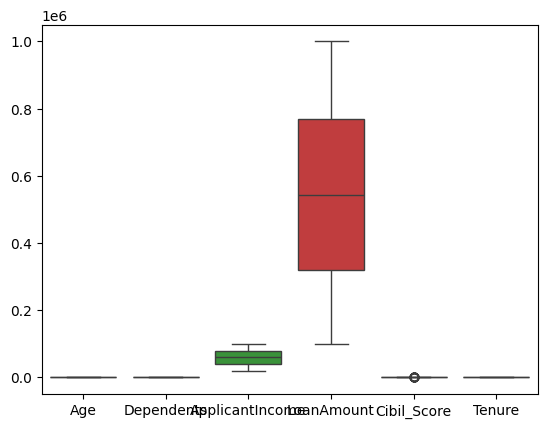

In [14]:
sns.boxplot(data=Bank)
plt.show()


In [15]:
Bank.head()

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status
0,LP001002,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes
2,LP001005,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No
3,LP001006,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No
4,LP001008,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No


In [16]:
def tenure_lab(Bank):
    if Bank["Tenure"] <= 6:
        return "Tenure_0_6"

    elif (Bank["Tenure"] > 6) & (Bank["Tenure"] <= 12):
        return "Tenure_7_12"

    elif (Bank["Tenure"] > 12) & (Bank["Tenure"] <= 24):
        return "Tenure_13_24"

    elif (Bank["Tenure"] > 24) & (Bank["Tenure"] <= 36):
        return "Tenure_25_36"

    elif Bank["Tenure"] > 36:
        return "Tenure_gt_36"

# Bank = x
Bank["Tenure_group"] = Bank.apply(lambda x: tenure_lab(x), axis=1)  #X = bank

In [17]:
Bank.head()

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status,Tenure_group
0,LP001002,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No,Tenure_gt_36
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes,Tenure_13_24
2,LP001005,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No,Tenure_7_12
3,LP001006,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No,Tenure_7_12
4,LP001008,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No,Tenure_7_12


In [18]:
Bank.Tenure_group.value_counts()

,count
Tenure_group,
Tenure_gt_36,267
Tenure_13_24,266
Tenure_25_36,259
Tenure_7_12,131
Tenure_0_6,58


In [19]:
Bank.Loan_Status.value_counts(normalize=True)*100

,proportion
Loan_Status,
No,72.579001
Yes,27.420999


In [20]:
import plotly.express as px

fig = px.pie(Bank,names='Loan_Status',color='Loan_Status',color_discrete_map={'Yes':'','No':'green'})
fig.show()

In [21]:
Bank_Yes= Bank[Bank["Loan_Status"] == "Yes"]

Bank_Yes

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status,Tenure_group
1,LP001003,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes,Tenure_13_24
7,LP001014,54,Male,Yes,1,Graduate,No,53213,368715,No,447,Semiurban,Bad,17,Yes,Tenure_13_24
9,LP001020,33,Male,Yes,0,Graduate,No,57348,347577,Yes,378,Semiurban,Bad,18,Yes,Tenure_13_24
13,LP001029,32,Male,No,4,Graduate,No,43208,309303,Yes,585,Rural,Medium,39,Yes,Tenure_gt_36
17,LP001036,45,Female,No,2,Graduate,No,27568,830422,No,659,Urban,Good,35,Yes,Tenure_25_36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,LP002802,24,Male,No,4,Graduate,No,29313,127392,No,618,Semiurban,Medium,36,Yes,Tenure_25_36
953,LP002858,57,Female,No,2,Graduate,No,91401,777888,No,726,Rural,Good,7,Yes,Tenure_7_12
956,LP002869,45,Male,Yes,4,Not Graduate,No,63617,421266,Yes,599,Rural,Medium,17,Yes,Tenure_13_24
960,LP002879,23,Male,Yes,4,Graduate,No,96201,996625,No,846,Rural,Good,22,Yes,Tenure_13_24


In [22]:
fig = px.sunburst(Bank_Yes, path=["Gender",'Education','Self_Employed','Tenure_group','Property_Area'])

fig.show()

In [24]:
Bank = Bank.drop('Loan_ID' , axis=1)
Bank.head()

,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status,Tenure_group
0,43,Male,No,3,Graduate,No,54005,334113,Yes,668,Urban,Good,43,No,Tenure_gt_36
1,57,Male,Yes,2,Graduate,No,28817,736026,Yes,684,Rural,Good,13,Yes,Tenure_13_24
2,25,Male,Yes,3,Graduate,Yes,99939,712432,Yes,788,Urban,Good,10,No,Tenure_7_12
3,44,Male,Yes,1,Not Graduate,No,38470,267161,Yes,888,Urban,Good,9,No,Tenure_7_12
4,58,Male,No,1,Graduate,No,28991,402474,Yes,703,Urban,Good,11,No,Tenure_7_12


In [25]:
Bank.select_dtypes(include=[np.number]).columns.tolist()

['Age', 'Dependents', 'ApplicantIncome', 'LoanAmount', 'Cibil_Score', 'Tenure']

In [27]:

Quantitative_Variable= Bank[Bank.select_dtypes(include=[np.number]).columns.tolist()]
Quantitative_Variable.head(3)

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure
0,43,3,54005,334113,668,43
1,57,2,28817,736026,684,13
2,25,3,99939,712432,788,10


#Converting Quallitative Variable into number

In [31]:
Qualitative_Variable= Bank[Bank.select_dtypes(include=['object']).columns.tolist()]
Qualitative_Variable.head(3)

,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status,Tenure_group
0,Male,No,Graduate,No,Yes,Urban,Good,No,Tenure_gt_36
1,Male,Yes,Graduate,No,Yes,Rural,Good,Yes,Tenure_13_24
2,Male,Yes,Graduate,Yes,Yes,Urban,Good,No,Tenure_7_12


In [32]:
from sklearn.preprocessing import LabelEncoder
Qualitative_Variable=Qualitative_Variable.apply(LabelEncoder().fit_transform)
Qualitative_Variable.head()

,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status,Tenure_group
0,1,0,0,0,1,2,1,0,4
1,1,1,0,0,1,0,1,1,1
2,1,1,0,1,1,2,1,0,3
3,1,1,1,0,1,2,1,0,3
4,1,0,0,0,1,2,1,0,3


In [33]:
Final_combined = pd.concat([Qualitative_Variable,Quantitative_Variable],axis=1)
Final_combined.head()

,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status,Tenure_group,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure
0,1,0,0,0,1,2,1,0,4,43,3,54005,334113,668,43
1,1,1,0,0,1,0,1,1,1,57,2,28817,736026,684,13
2,1,1,0,1,1,2,1,0,3,25,3,99939,712432,788,10
3,1,1,1,0,1,2,1,0,3,44,1,38470,267161,888,9
4,1,0,0,0,1,2,1,0,3,58,1,28991,402474,703,11


Data Partition

In [36]:
from sklearn.model_selection import train_test_split

#Define or input vairable (x) & output variable
X = Final_combined.drop('Loan_Status',axis=1)
y = Final_combined['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=56)

In [39]:
train =pd.concat([X_train,y_train],axis=1)
train.head()


,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Tenure_group,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Loan_Status
920,1,1,0,1,1,0,1,4,29,3,98044,514905,700,47,0
666,1,1,0,0,1,1,1,4,20,1,40361,203352,722,46,0
797,0,1,0,0,1,0,1,3,26,0,81575,180754,803,9,0
925,0,0,0,0,0,0,0,0,49,5,30054,351494,327,6,1
735,1,1,0,0,1,0,1,4,38,4,53256,336285,800,45,0


Model Building

In [44]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
Model3 =sfs(logreg, n_features_to_select=5 , direction='forward' , scoring='accuracy' ,cv=5)
Model3.fit(X_train,y_train)

SequentialFeatureSelector(estimator=LogisticRegression(),
                          n_features_to_select=5, scoring='accuracy')

In [45]:
Model3.feature_names_in_

array(['Gender', 'Married', 'Education', 'Self_Employed',
       'Previous_Loan_Taken', 'Property_Area', 'Customer_Bandwith',
       'Tenure_group', 'Age', 'Dependents', 'ApplicantIncome',
       'LoanAmount', 'Cibil_Score', 'Tenure'], dtype=object)

In [46]:
Model3.get_feature_names_out()

array(['Education', 'Self_Employed', 'Previous_Loan_Taken', 'Age',
       'Cibil_Score'], dtype=object)

In [51]:
X_train = X_train.loc[:, ['Education', 'Self_Employed', 'Previous_Loan_Taken', 'Age','Cibil_Score']]
X_train

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score
920,0,1,1,29,700
666,0,0,1,20,722
797,0,0,1,26,803
925,0,0,0,49,327
735,0,0,1,38,800
...,...,...,...,...,...
418,0,0,1,38,601
192,1,0,1,60,377
399,0,0,0,51,475
484,0,0,1,42,613


In [52]:
from  sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
output = logreg.fit(X_train,y_train)   #model = output

In [53]:
output.intercept_  # beto

array([8.02295039])

In [54]:
output.coef_ # Beta 1

array([[ 0.06769233, -0.20542309, -3.58235348,  0.01291169, -0.00965113]])

In [55]:
output.feature_names_in_

array(['Education', 'Self_Employed', 'Previous_Loan_Taken', 'Age',
       'Cibil_Score'], dtype=object)

 Step 6 :Prediction on Train Data set

In [56]:
train =pd.concat([X_train,y_train],axis=1)
train.head()

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status
920,0,1,1,29,700,0
666,0,0,1,20,722,0
797,0,0,1,26,803,0
925,0,0,0,49,327,1
735,0,0,1,38,800,0


In [58]:
train['Probability'] = output.predict_proba(X_train)[:,1]
train

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status,Probability
920,0,1,1,29,700,0,0.104689
666,0,0,1,20,722,0,0.093699
797,0,0,1,26,803,0,0.048635
925,0,0,0,49,327,1,0.995929
735,0,0,1,38,800,0,0.057885
...,...,...,...,...,...,...,...
418,0,0,1,38,601,0,0.295444
192,1,0,1,60,377,1,0.838148
399,0,0,0,51,475,1,0.983652
484,0,0,1,42,613,0,0.282265


In [61]:
train['Predicted'] =np.where(train['Probability'] >=0.7,1,0)
train.head()

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status,Probability,Predicted
920,0,1,1,29,700,0,0.104689,0
666,0,0,1,20,722,0,0.093699,0
797,0,0,1,26,803,0,0.048635,0
925,0,0,0,49,327,1,0.995929,1
735,0,0,1,38,800,0,0.057885,0


In [62]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(train['Predicted'] , train['Loan_Status'])
matrix

array([[553,  95],
       [  9, 127]])

In [63]:
from sklearn.metrics import classification_report
print(classification_report(train['Loan_Status'] , train['Predicted']))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       562
           1       0.93      0.57      0.71       222

    accuracy                           0.87       784
   macro avg       0.89      0.78      0.81       784
weighted avg       0.88      0.87      0.86       784



In [64]:
X_test = X_test.loc[:, ['Education', 'Self_Employed', 'Previous_Loan_Taken', 'Age','Cibil_Score']]
X_test

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score
607,1,0,1,36,707
401,1,0,1,32,415
634,1,0,1,30,839
98,1,0,1,33,862
143,0,0,1,52,643
...,...,...,...,...,...
73,1,0,0,45,359
610,0,0,1,54,708
520,1,0,1,56,791
786,0,0,1,39,574


In [65]:
test=pd.concat([X_test,y_test],axis=1)
test.head()

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status
607,1,0,1,36,707,0
401,1,0,1,32,415,1
634,1,0,1,30,839,0
98,1,0,1,33,862,0
143,0,0,1,52,643,0


In [66]:
test['Probability'] = output.predict_proba(X_test)[:,1]
test.head()

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status,Probability
607,1,0,1,36,707,0,0.135845
401,1,0,1,32,415,1,0.714276
634,1,0,1,30,839,0,0.039103
98,1,0,1,33,862,0,0.032771
143,0,0,1,52,643,0,0.250928


In [68]:
test['Predicted']=np.where(test['Probability']>=0.7,1,0)
test.head()

,Education,Self_Employed,Previous_Loan_Taken,Age,Cibil_Score,Loan_Status,Probability,Predicted
607,1,0,1,36,707,0,0.135845,0
401,1,0,1,32,415,1,0.714276,1
634,1,0,1,30,839,0,0.039103,0
98,1,0,1,33,862,0,0.032771,0
143,0,0,1,52,643,0,0.250928,0
